In [1]:
import zipfile, pandas as pd

with zipfile.ZipFile("/content/dataset.zip") as z:
    print(z.namelist())          # phải in ra ['data.csv']
    z.extractall("/content/data")

df = pd.read_csv("/content/data/data.csv")
print(df.shape)                  # phải in ra (569, 33)
df.head()

['data.csv']
(569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs("figures", exist_ok=True)   # thư mục chứa hình

df = df.drop(columns=["id", "Unnamed: 32"], errors="ignore")   # bỏ cột id và cột rỗng
df["target"] = df["diagnosis"].map({"B": 0, "M": 1})            # B=0 (lành), M=1 (ác)

print(df.shape)              # phải in ra (569, 31)
print("Ô thiếu:", df.isna().sum().sum(), "| Dòng trùng:", df.duplicated().sum())

(569, 32)
Ô thiếu: 0 | Dòng trùng: 0


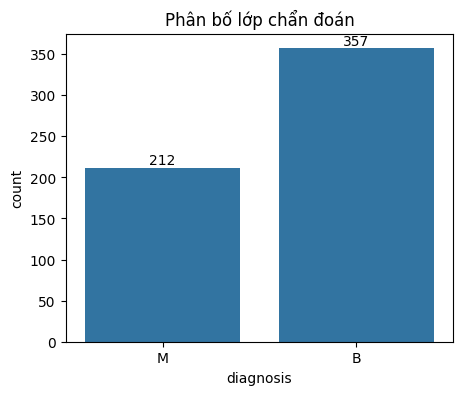

diagnosis
B    357
M    212
Name: count, dtype: int64
diagnosis
B    0.627
M    0.373
Name: proportion, dtype: float64


In [3]:
plt.figure(figsize=(5, 4))
ax = sns.countplot(x="diagnosis", data=df)
for c in ax.containers:
    ax.bar_label(c)
plt.title("Phân bố lớp chẩn đoán")
plt.savefig("figures/eda1_target.png", dpi=150, bbox_inches="tight")
plt.show()

print(df["diagnosis"].value_counts())
print(df["diagnosis"].value_counts(normalize=True).round(3))

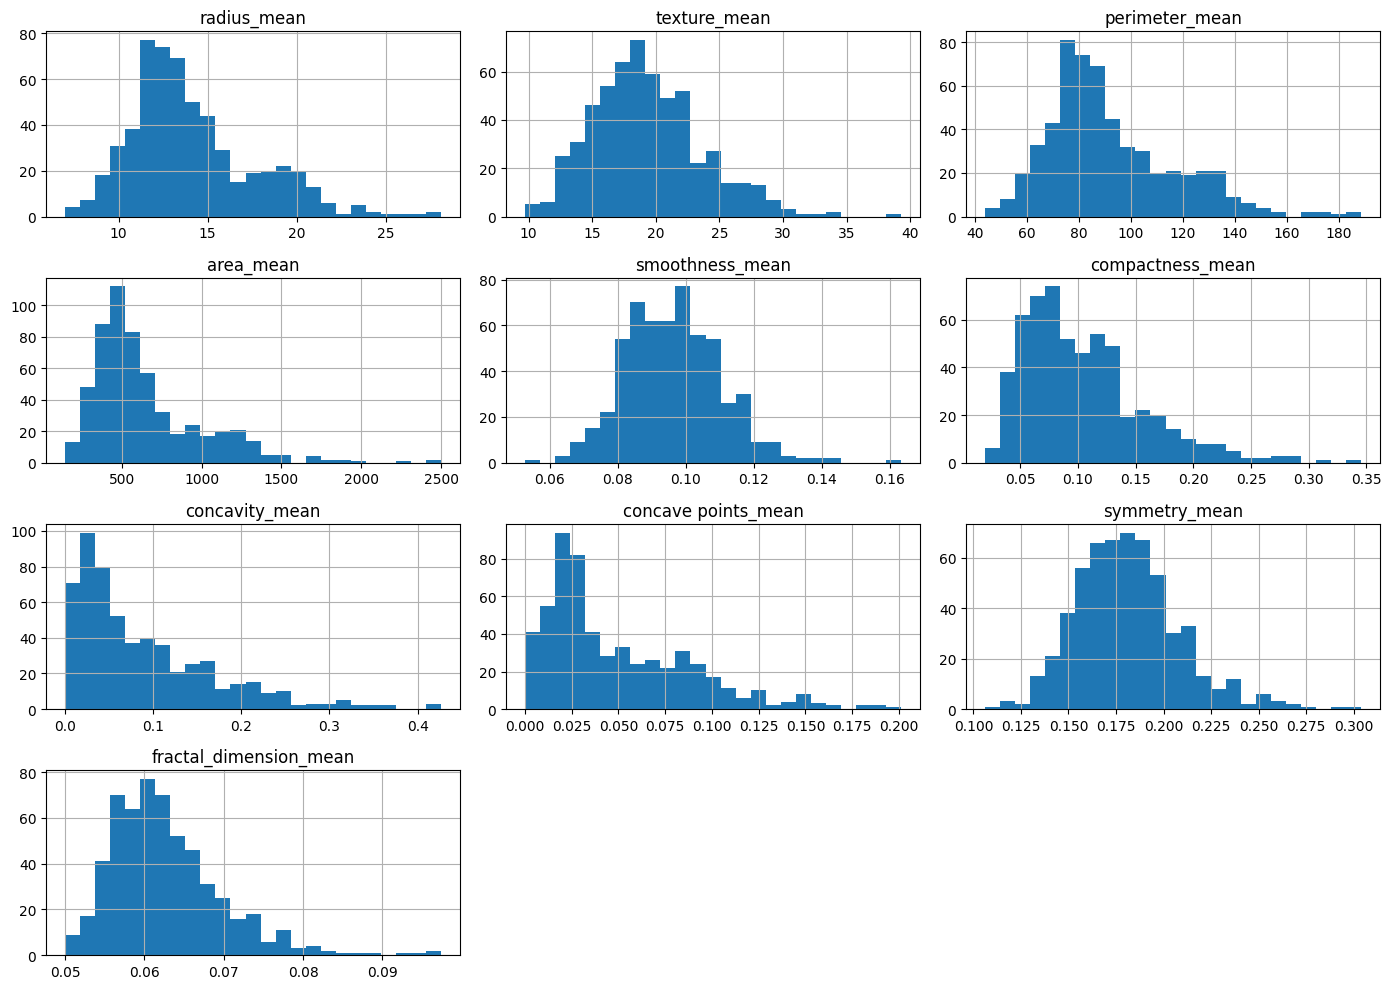

area_mean                 1.65
concavity_mean            1.40
fractal_dimension_mean    1.30
compactness_mean          1.19
concave points_mean       1.17
perimeter_mean            0.99
radius_mean               0.94
symmetry_mean             0.73
texture_mean              0.65
smoothness_mean           0.46
dtype: float64


In [4]:
cols_mean = [c for c in df.columns if c.endswith("_mean")]
df[cols_mean].hist(bins=25, figsize=(14, 10))
plt.tight_layout()
plt.savefig("figures/eda2_hist.png", dpi=150)
plt.show()

print(df[cols_mean].skew().round(2).sort_values(ascending=False))   # độ lệch: dương lớn = lệch phải

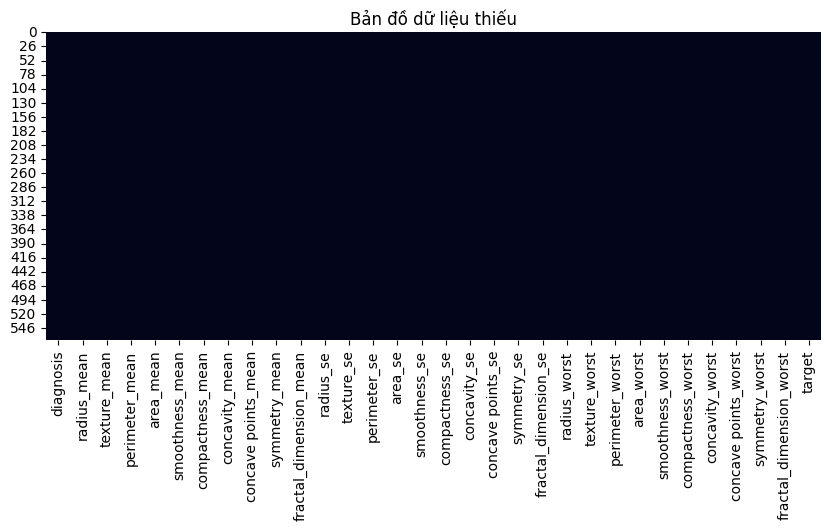

Tổng ô thiếu: 0


In [5]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Bản đồ dữ liệu thiếu")
plt.savefig("figures/eda3_missing.png", dpi=150, bbox_inches="tight")
plt.show()

print("Tổng ô thiếu:", df.isna().sum().sum())

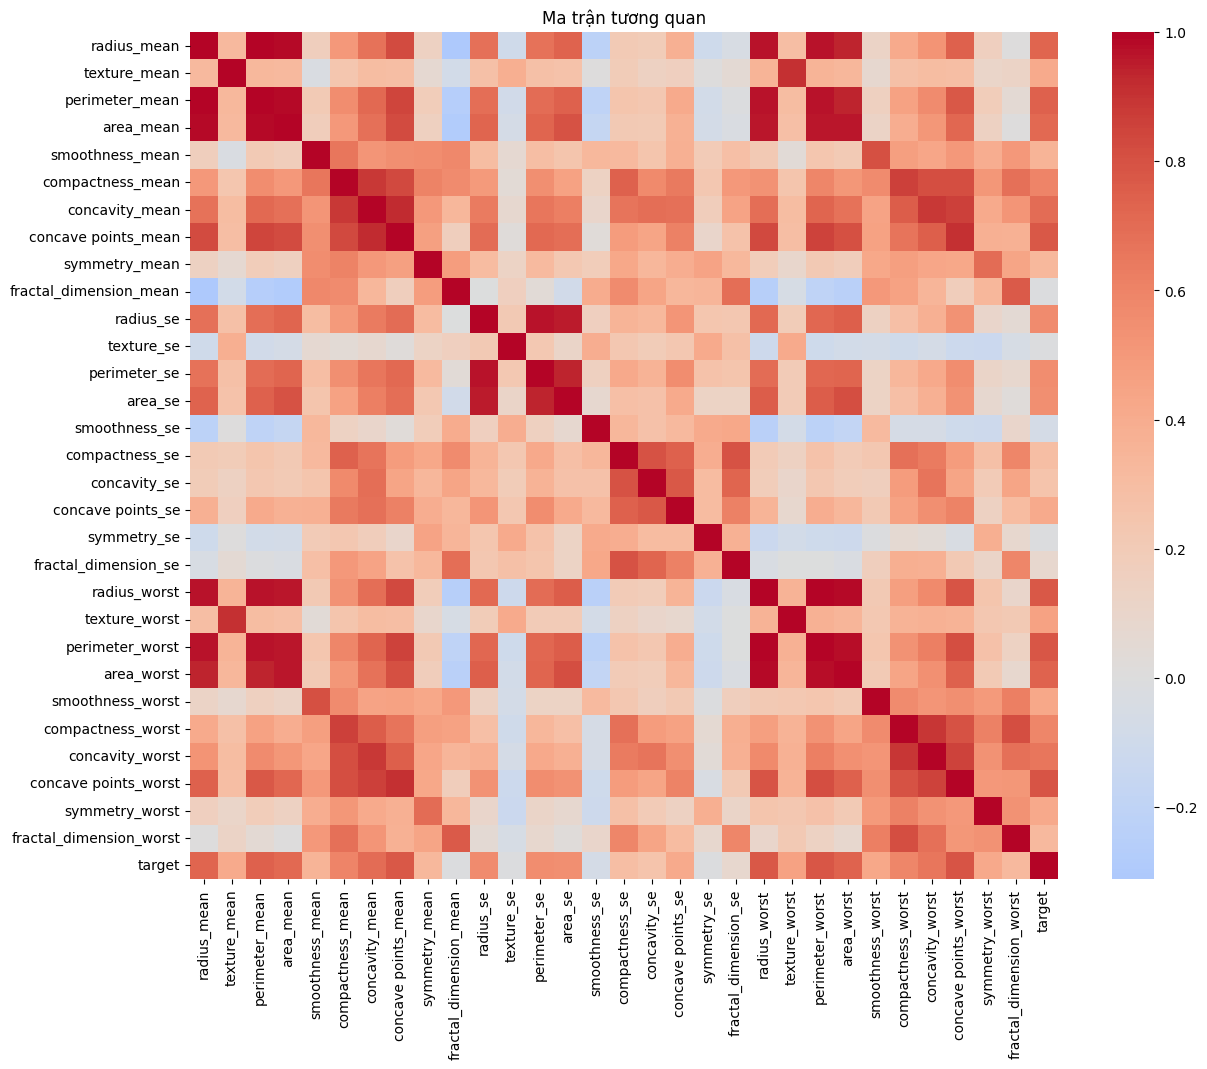

Tương quan mạnh nhất với target:
concave points_worst    0.794
perimeter_worst         0.783
concave points_mean     0.777
radius_worst            0.776
perimeter_mean          0.743
area_worst              0.734
radius_mean             0.730
area_mean               0.709
Name: target, dtype: float64

radius_mean vs perimeter_mean: 0.998
radius_mean vs area_mean: 0.987


In [6]:
corr = df.drop(columns="diagnosis").corr()
plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Ma trận tương quan")
plt.savefig("figures/eda4_corr.png", dpi=150, bbox_inches="tight")
plt.show()

print("Tương quan mạnh nhất với target:")
print(corr["target"].drop("target").abs().sort_values(ascending=False).head(8).round(3))
print("\nradius_mean vs perimeter_mean:", round(corr.loc["radius_mean", "perimeter_mean"], 3))
print("radius_mean vs area_mean:", round(corr.loc["radius_mean", "area_mean"], 3))

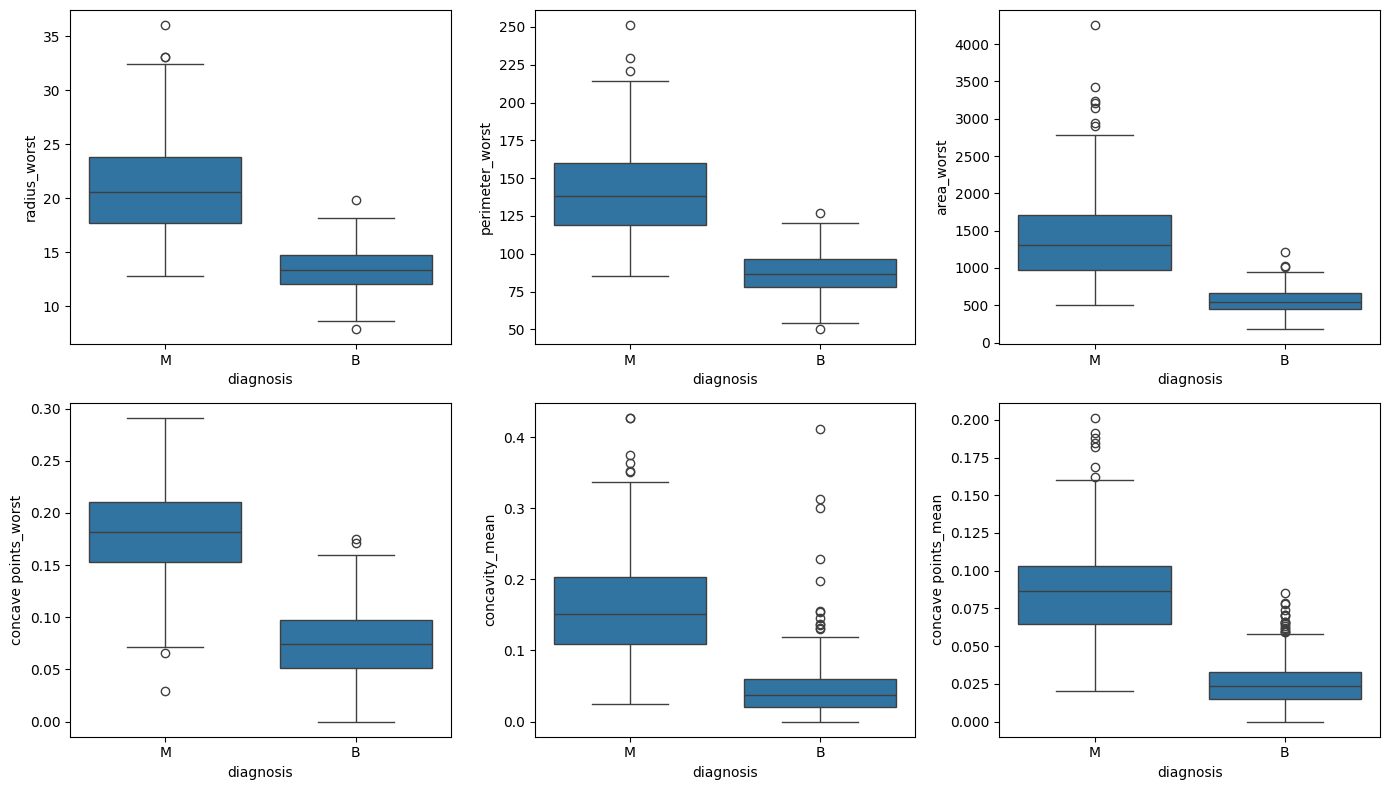

           radius_worst  perimeter_worst  area_worst  concave points_worst  \
diagnosis                                                                    
B                 13.35            86.92       547.4                 0.074   
M                 20.59           138.00      1303.0                 0.182   

           concavity_mean  concave points_mean  
diagnosis                                       
B                   0.037                0.023  
M                   0.151                0.086  


In [7]:
top = ["radius_worst", "perimeter_worst", "area_worst",
       "concave points_worst", "concavity_mean", "concave points_mean"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for a, c in zip(axes.ravel(), top):
    sns.boxplot(x="diagnosis", y=c, data=df, ax=a)
plt.tight_layout()
plt.savefig("figures/eda5_box.png", dpi=150)
plt.show()

print(df.groupby("diagnosis")[top].median().round(3))   # trung vị mỗi lớp

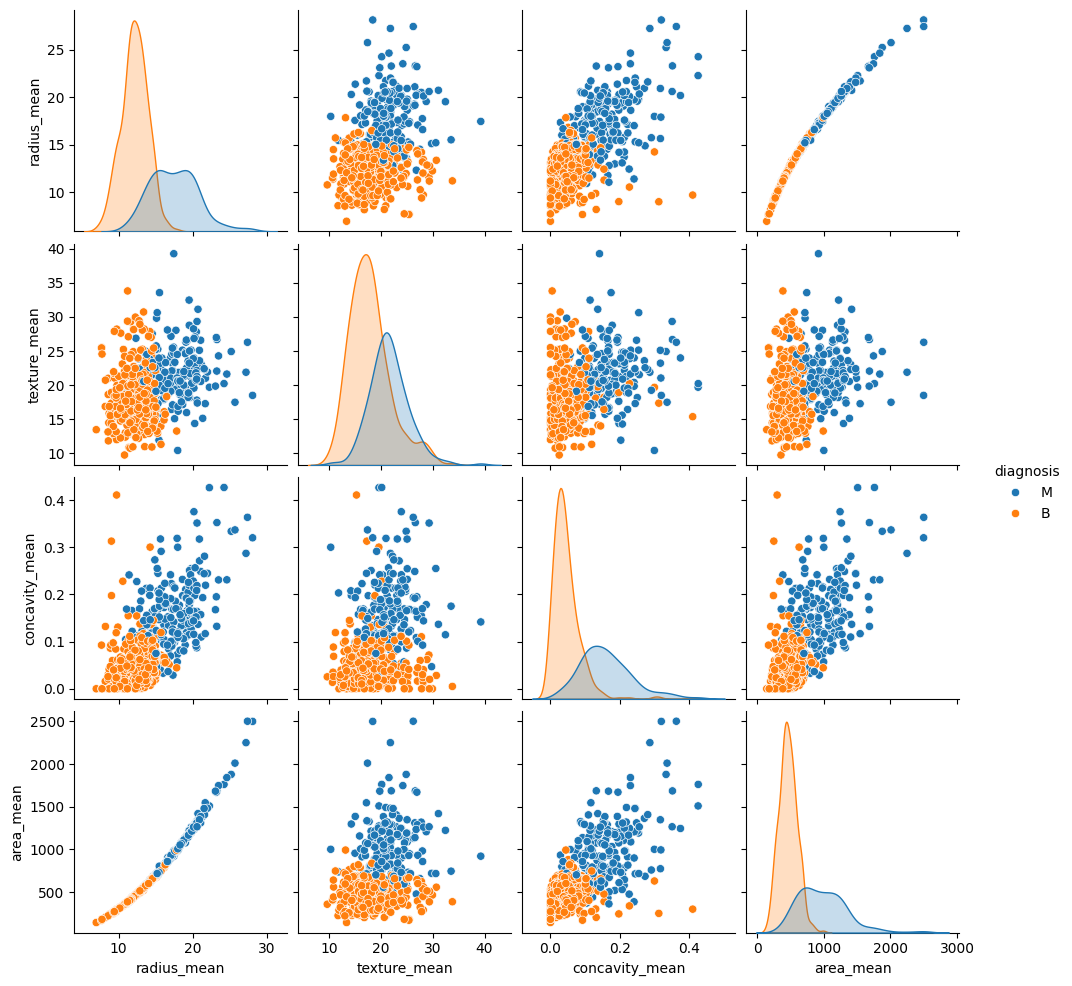

In [8]:
g = sns.pairplot(df[["radius_mean", "texture_mean", "concavity_mean", "area_mean", "diagnosis"]],
                 hue="diagnosis")
g.savefig("figures/eda6_pair.png", dpi=150)
plt.show()

In [9]:
import shutil
from google.colab import files

shutil.make_archive("figures", "zip", "figures")
files.download("figures.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>